# repgen3d pipeline v2 - module-driven 3D twin-aware workflow
Same scientific pipeline as `repgen3mcgs1.ipynb` but orchestrated through
`upxo.pxtal.twinned_simple_3d` module classes.  Parts A and B are unchanged
(EBSD pre-processing via `repgen2d`); Parts C onwards use
`TwinnedSimple3DBase`, `OrientationAssigner3D`, `TwinGenerator3D`,
`StructureCleaner3D`, and `RepresentativenessValidator3D`.

## Part A - EBSD pre-processing

### S1  Configuration

In [1]:
# -- EBSD input ----------------------------------------------------------------
CTF_FILE        = r'C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2.ctf'
MIN_GRAIN_SIZE  = 10    # pixels - grains smaller than this are flagged -2
MISORI_TOL      = 8     # degrees - grain-boundary misorientation threshold
CROP_REGION     = [1, 1, 99, 99]   # [xstart%, ystart%, xend%, yend%]

# -- Simulated grain structure -------------------------------------------------
INPUT_DASHBOARD = r'C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls'
TSLICE_INDEX    = 10    # index into pxt.m[] used to pick the best-matching tslice

### S2  Import statements

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.repgen.repgen2dmcgs import repgen2d
from upxo.ggrowth.mcgs import mcgs

### S3  EBSD reader - write subsampled CTF, load, crop

In [3]:
import os
from upxo.interfaces.defdap.ebsd_reader import EBSDReader, write_subsampled_ctf

# -- paths -------------------------------------------------------------------
CTF_SRC = CTF_FILE
CTF_DST = CTF_SRC.replace('.ctf', '_s3.ctf')
STRIDE  = 2

out_path = write_subsampled_ctf(CTF_SRC, CTF_DST, stride_x=STRIDE, stride_y=STRIDE)
print(f'Written          : {out_path}')
print(f'Size original    : {os.path.getsize(CTF_SRC) / 1e6:.1f} MB')
print(f'Size sub-sampled : {os.path.getsize(CTF_DST) / 1e6:.1f} MB')

Written          : C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2_s3.ctf
Size original    : 43.1 MB
Size sub-sampled : 10.8 MB


### S4  Initiate repgen2d

In [4]:
CTF_FILE = CTF_DST
rdr = EBSDReader.from_file(CTF_FILE, min_grain_size=MIN_GRAIN_SIZE, misori_tol=MISORI_TOL)
rdr = rdr.crop(CROP_REGION, inplace=False)

Loaded EBSD data (dimensions: 513 x 363 pixels, step size: 0.8 um)
Finished building quaternion array (0:00:00) 
Finished finding grain boundaries (0:00:01) 
Finished finding grains (0:00:00) 
[crop] region=[1, 1, 99, 99]%  →  rows 4:359, cols 5:508  |  original 363×513  →  cropped 355×503


### S5  Compute MDF

[rechar_lfi] Map 355×503  |  unknown pixels: 3619 (2.03%)  |  connectivity=4
[rechar_lfi] Step 1/5 — labelling unknown connected components …
[rechar_lfi]           1569 connected components found.
[rechar_lfi] Step 2/5 — computing grain adjacency …
[rechar_lfi] Step 3/5 — assigning CC pixels to grains …


  assigning CCs:   0%|          | 0/1569 [00:00<?, ?CC/s]

[rechar_lfi]           1569/1569 CCs assigned (3619 pixels filled).
[rechar_lfi] Step 4/5 — computing grain-average orientations (vectorized) …
[rechar_lfi]           381 unique grains to average over.
[rechar_lfi]           averaging Euler channels (3) …
[rechar_lfi]           averaging quaternion channels (4) …
[rechar_lfi]           orientation averages ready.
[rechar_lfi] Step 5/5 — writing orientations for 3619 unknown pixels (vectorised, no loop) …
[rechar_lfi]           3619 pixels written (0 isolated islands left unfilled).
[rechar_lfi] Done.
clean_and_rechar_from_rdr() completed in 3.4 s
Non-positive pixels remaining : 111
Grains after cleaning         : 1058
Neighbour entries             : 1058
prop_ebsd grain count         : 1058
Property                      mean         std         min         max   count
---------------------------------------------------------------------------
area                       107.949     212.303       6.400    2436.480    1058
perimeter      

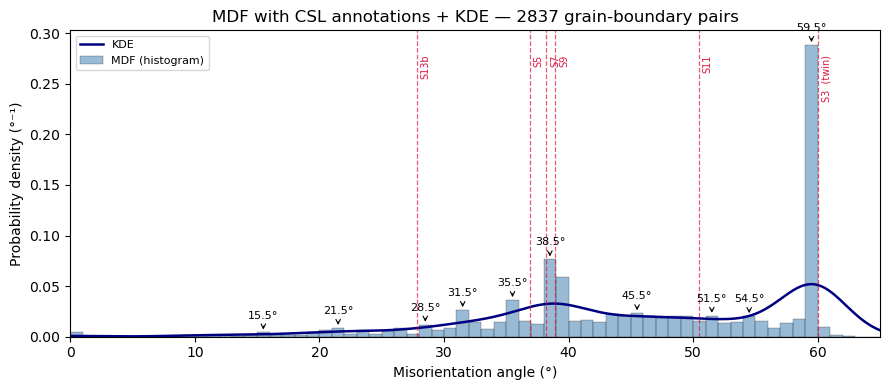

In [5]:
rg = repgen2d.from_tgs(tgs=None, tgstype='ebsd2d', ebsd_file=CTF_FILE)
rg.set_ebsd_step(rdr.step_size)
rg.clean_and_rechar_from_rdr(rdr, connectivity=4, min_grain_size=MIN_GRAIN_SIZE)
rg.compute_ebsd_stats()

mdf, peaks = rg.compute_mdf_ebsd()

### S6  Select MDF peaks of interest

In [6]:
selected_peaks = rg.select_mdf_peaks(peaks)

Select which MDF peaks to retain for downstream analysis:


### S7  Plot MDF with selected peaks

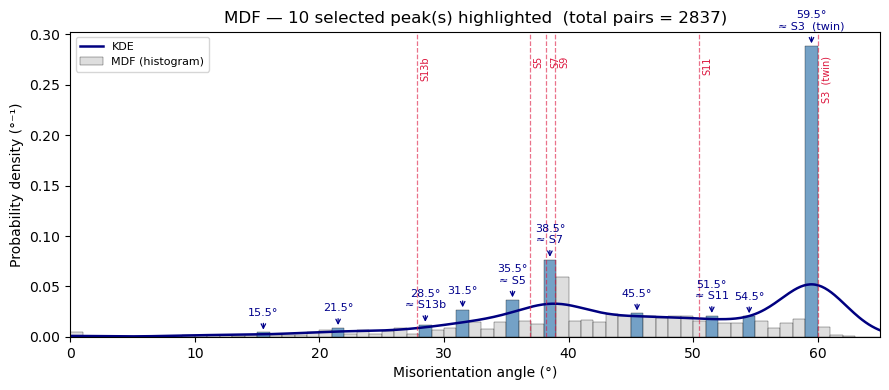

Selected peak angles : [15.5, 21.5, 28.5, 31.5, 35.5, 38.5, 45.5, 51.5, 54.5, 59.5]


In [7]:
rg.plot_mdf_selected(mdf, peaks, selected_peaks)

### S8  Segregate CSL pairs and visualise

CSL type            ref °   pairs   grains
──────────────────────────────────────────
S13b                27.80      84      145
S5                  36.87     343      453
S7                  38.21     466      597
S11                 50.48     211      317
S3  (twin)          60.00     898      948


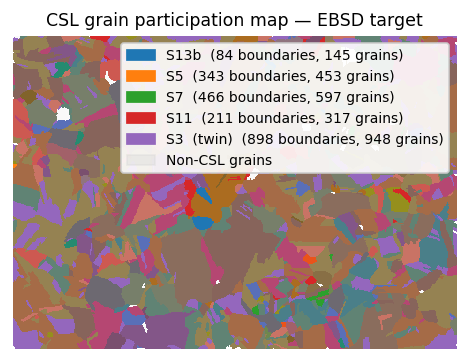

In [8]:
csl_grains = rg.segregate_csl_pairs(mdf, selected_peaks, peaks['csl'], peaks['csl_tol'])
rg.see_csl_grain_map(csl_grains, figsize=(6, 3), dpi=125)

### S9  CSL volume fractions

CSL type            ref °   grains    pixels   VF (indexed)   VF (total)
──────────────────────────────────────────────────────────────────────
S13b                27.80      145     50119        28.09%      28.07%
S5                  36.87      453    103827        58.18%      58.15%
S7                  38.21      597    132019        73.98%      73.93%
S11                 50.48      317     94818        53.13%      53.10%
S3  (twin)          60.00      948    165325        92.64%      92.59%


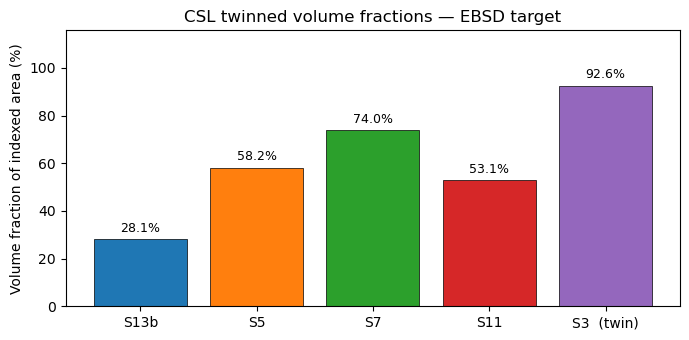

In [9]:
cslvf = rg.compute_csl_volume_fractions(csl_grains)

### S10  Identify parent grains

CSL type            ref °   pairs   pure parents   pure twins   intermediates
───────────────────────────────────────────────────────────────────────────
S13b                27.80      84             67           74               4
S5                  36.87     343            178          214              61
S7                  38.21     466            212          300              85
S11                 50.48     211            132          158              27
S3  (twin)          60.00     898            243          497             208


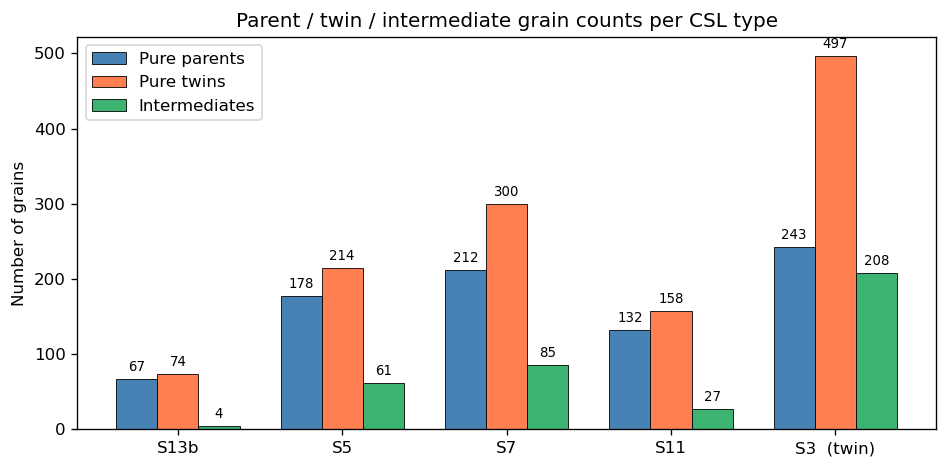

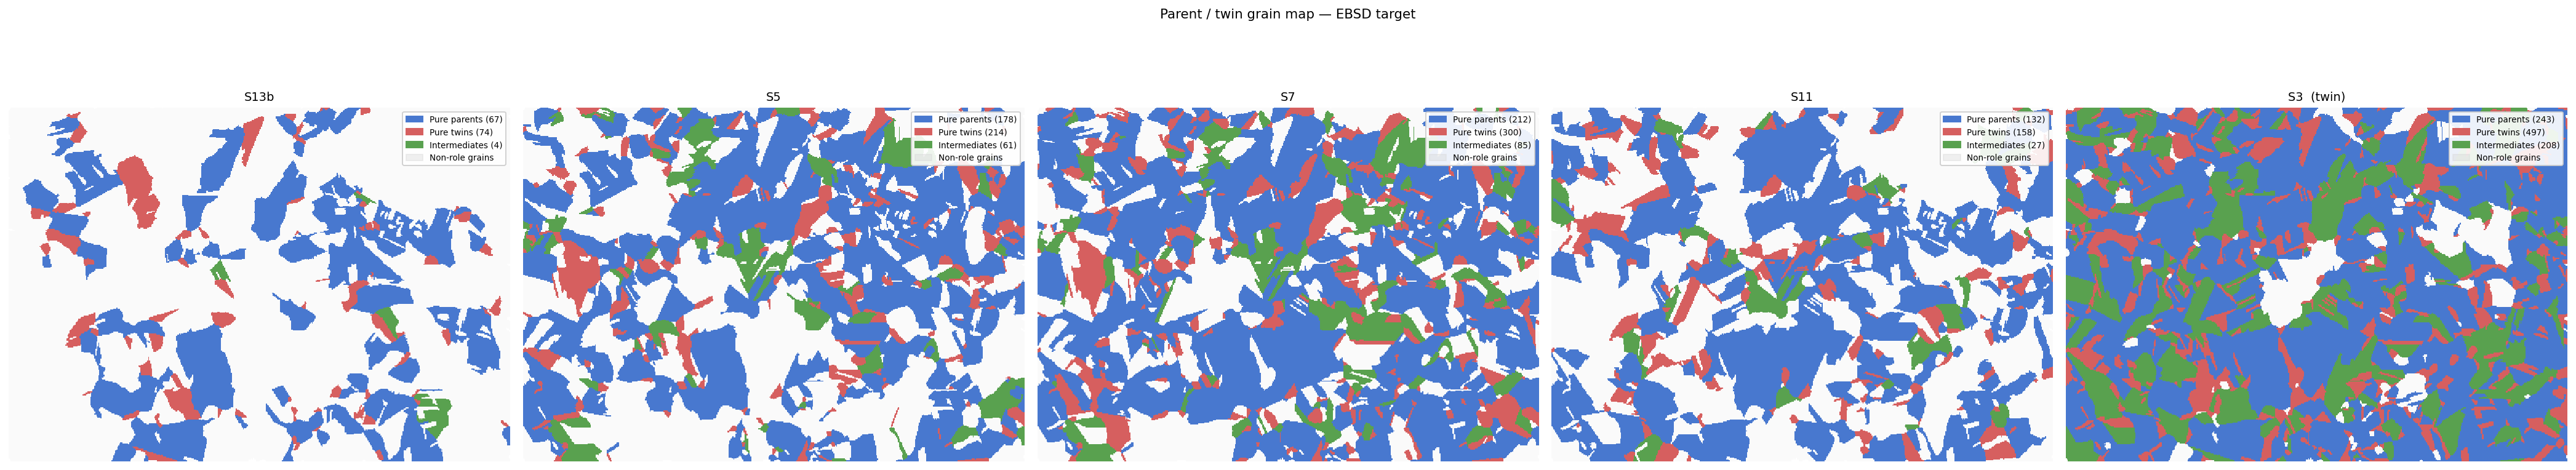

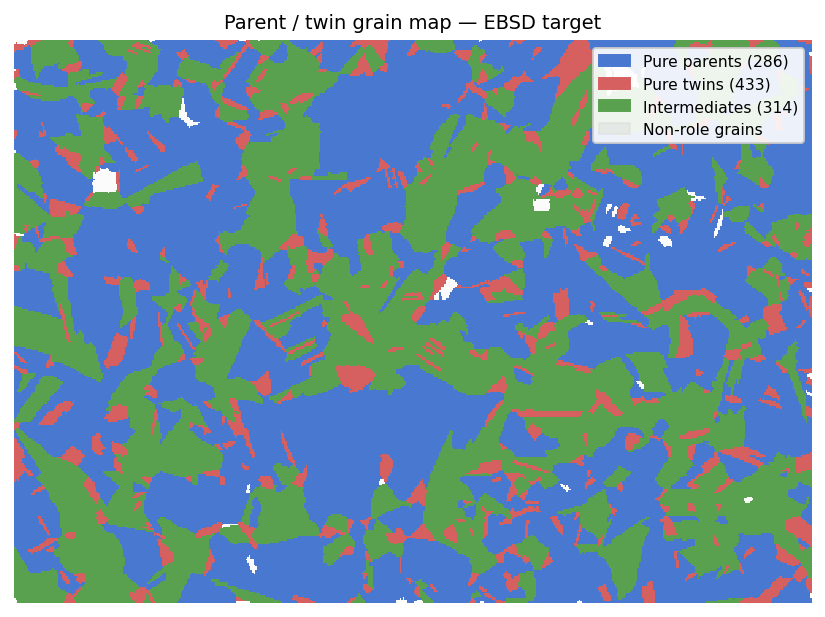

In [10]:
parent_info = rg.identify_parent_grains(csl_grains, plot_parent_twin_maps=True, plot_combined_parent_twin_map=True)

### S11  EBSD twin area fractions - compute

In [11]:
tvf = rg.compute_ebsd_tvf(parent_info)
print(f"CSL label                  : {tvf['csl_label']}")
print(f"Overall twin area fraction : {tvf['overall_twin_frac']:.4f}")
print(f"  Pure parents             : {tvf['pure_parent_frac']:.4f}")
print(f"  Primary twins (1st gen)  : {tvf['primary_twin_frac']:.4f}")
print(f"  Secondary twins (2nd gen): {tvf['secondary_twin_frac']:.4f}")
print(f"  Intermediate twins       : {tvf['intermediate_frac']:.4f}")
print(f"  No-role grains           : {tvf['non_role_frac']:.4f}")
print(f"  {'-' * 41}")
print(f"  Sum check                : {tvf['overall_twin_frac'] + tvf['pure_parent_frac'] + tvf['non_role_frac']:.4f}")

compute_ebsd_tvf: auto-selected CSL label  → "S13b"
  Available labels: ['S13b', 'S5', 'S7', 'S11', 'S3  (twin)']
CSL label                  : S13b
Overall twin area fraction : 0.0574
  Pure parents             : 0.2234
  Primary twins (1st gen)  : 0.0478
  Secondary twins (2nd gen): 0.0014
  Intermediate twins       : 0.0082
  No-role grains           : 0.7191
  -----------------------------------------
  Sum check                : 1.0000


### S12  EBSD twin area fractions - plot

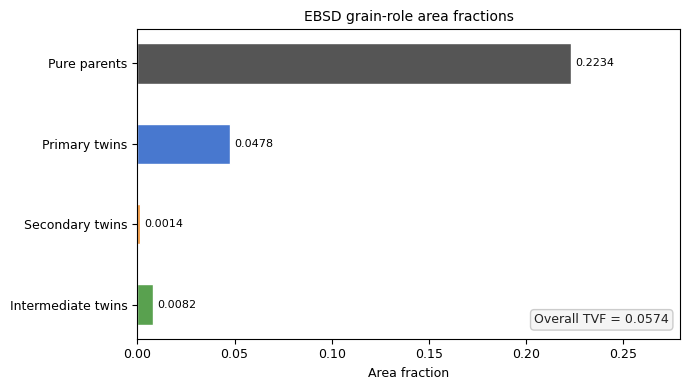

In [12]:
rg.plot_ebsd_tvf(tvf)

### S13  Build merged EBSD labelled feature image (LFI)

[merge_info]  merged grains: 157  |  with twins: 132  |  twin-hosting fraction: 0.8408


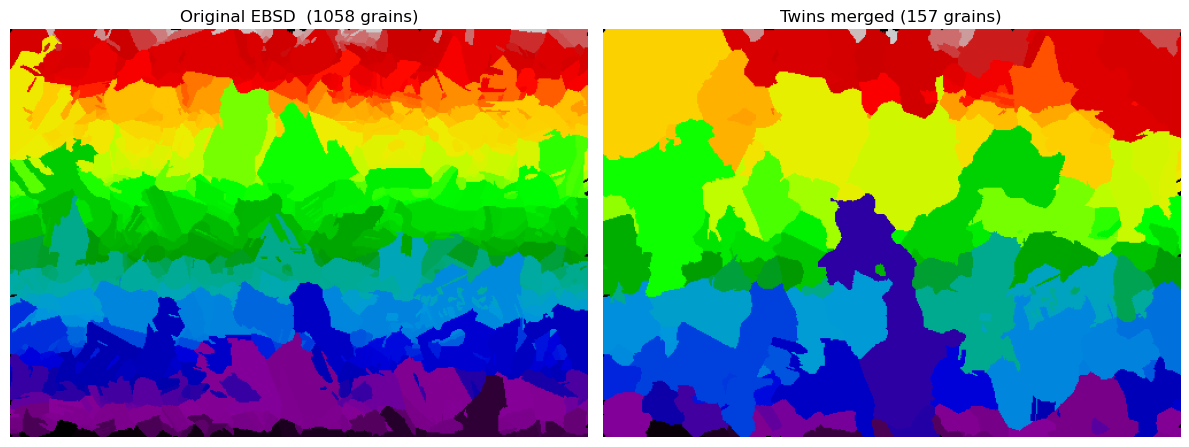

In [13]:
rg.build_merged_ebsd_lfi(parent_info)

### S14  Merge provenance

In [14]:
print(f"Merged grains total    : {rg.merge_info['n_merged_total']}")
print(f"Grains with twins      : {rg.merge_info['n_hosting_grains']}")
print(f"Twin-hosting fraction  : {rg.merge_info['twin_hosting_fraction']:.4f}")

Merged grains total    : 157
Grains with twins      : 132
Twin-hosting fraction  : 0.8408


### S14b  EBSD parent-state MDF (merged: twins absorbed into parents)
Used as the pre-twin comparison reference in S27.  The full `mdf` (twins present, Sigma3 peak at ~60 deg) is reserved for the post-twin comparison in S33.

In [15]:
from upxo.xtalphy.crystal_orientation import grain_avg_quats, compute_mdf_from_quats
from upxo.gsdataops.gid_ops import find_neighs2d

# Grain-average quaternions for the merged (parent-only) EBSD structure
ebsd_gids_m, ebsd_q_m = grain_avg_quats(rg.lfi_ebsd_merged, rg.quat_ebsd)
gid2q_m = {int(g): ebsd_q_m[i] for i, g in enumerate(ebsd_gids_m)}

# Broadcast back to a per-pixel quaternion field
import numpy as np
quat_merged_field = np.zeros(rg.lfi_ebsd_merged.shape + (4,), dtype=np.float64)
for gid, q in gid2q_m.items():
    quat_merged_field[rg.lfi_ebsd_merged == gid] = q

# Neighbour graph and MDF for the merged structure
neigh_m_raw = find_neighs2d(rg.lfi_ebsd_merged.astype(np.int32), conn=4)
neigh_m = {int(g): [int(n) for n in ns] for g, ns in neigh_m_raw.items()}
mdf_merged = compute_mdf_from_quats(
    rg.lfi_ebsd_merged, quat_merged_field, neigh_m, n_bins=65, angle_range=(0.0, 65.0))

print(f'EBSD merged (parent-state) MDF - mean: {mdf_merged["mean_angle"]:.2f} deg, '
      f'n_pairs: {mdf_merged["n_pairs"]}')
print(f'EBSD full (with twins)    MDF - mean: {mdf["mean_angle"]:.2f} deg')
print('mdf_merged will be used for pre-twin comparison (S27).')
print('mdf (full) will be used for post-twin comparison (S33).')

EBSD merged (parent-state) MDF - mean: 39.10 deg, n_pairs: 363
EBSD full (with twins)    MDF - mean: 46.18 deg
mdf_merged will be used for pre-twin comparison (S27).
mdf (full) will be used for post-twin comparison (S33).


## Part B - Grain role property analysis (twin GS)

### S15  Select GS properties for twin analysis

In [16]:
twinPropSelection = rg.selectProps_twinGS()

### S16  Read selected properties and view distributions

Properties : ['area']
Groups     : ['pure_parents', 'pure_twins', 'intermediates', 'non_role']


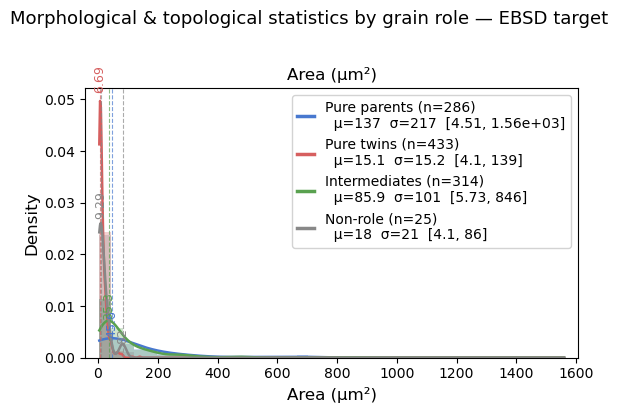

In [17]:
twinProps = rg.readProps_twinGS(twinPropSelection)
rg.see_grain_role_property_stats(parent_info, twinProps)

## Part C - 3D MC generation and base setup

### S17  Configuration

In [18]:
# -- 3D MC ---------------------------------------------------------------
INPUT_DASHBOARD = r'C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls'
MC_TIME_START    = 2
MC_TIME_END      = -1
MC_TIME_STEP     = 2
print('Configuration loaded.')

Configuration loaded.


### S18  Run 3D MC simulation

In [19]:
pxt = mcgs(study='independent', input_dashboard=INPUT_DASHBOARD)
print(pxt)
print('Simulating...')
pxt.simulate(verbose=False)
print(f'Simulation complete. Temporal slices: {len(pxt.m)}')

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls
Algo_hops details
(('300b', 100),)
[False]
x:(0.0,100.0,1.0), y:(0.0,100.0,1.0), z:(0.0,100.0,1.0).
Simulating...

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 24
     Dimensionality: 3
Using ALG-300b
////////////////////////////////
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stor

### S19  Select temporal slice and build TwinnedSimple3DBase

In [20]:
# -- Temporal slice sampling config ------------------------------------
MC_SLICE_START          = 10    # starting positional index into pxt.m
MC_SLICE_STEP           = 5     # sample every N-th slice

# -- 2D-equivalent grain count config (fair comparison with EBSD) ------
# EBSD gives a 2D cross-section; we compare to the mean grain count
# across 2D slices extracted from the 3D MC structure.
MC_COMPARE_N_SLICES     = 5             # slices per axis
MC_COMPARE_AXES         = ['x', 'y', 'z']  # axes to include

n_shown = len(range(MC_SLICE_START, len(pxt.m), MC_SLICE_STEP))
n_total_slices = MC_COMPARE_N_SLICES * len(MC_COMPARE_AXES)
print(f'Sampling {n_shown} temporal slices from pxt.m[{MC_SLICE_START}::step={MC_SLICE_STEP}]')
print(f'Each slice scored by mean 2D grain count across {n_total_slices} slices '
      f'({MC_COMPARE_N_SLICES} per axis: {MC_COMPARE_AXES})')

Sampling 23 temporal slices from pxt.m[10::step=5]
Each slice scored by mean 2D grain count across 15 slices (5 per axis: ['x', 'y', 'z'])


In [21]:
from upxo.pxtal.twinned_simple_3d import TwinnedSimple3DBase

# EBSD reference parent grain count (from Part A)
ebsd_n_parents = len(parent_info[tvf['csl_label']]['pure_parents'])

# Rank slices by 2D-equivalent grain count and display single-select widget
rank_info = TwinnedSimple3DBase.rank_temporal_slices_by_n(
    pxt,
    start=MC_SLICE_START,
    step=MC_SLICE_STEP,
    ebsd_n_parents=ebsd_n_parents,
    n_comparison_slices=MC_COMPARE_N_SLICES,
    comparison_axes=MC_COMPARE_AXES,
)
tslice_wdg = TwinnedSimple3DBase.select_temporal_slice(rank_info, ebsd_n_parents)

In [22]:
# Read selected key from widget above
tslice_key = tslice_wdg.value
print(f'Selected temporal slice: t={tslice_key}')

base = TwinnedSimple3DBase.from_mcgs(pxt, tslice_key, rng_seed=0)
base.char_morphology(volnv=True, eqdia=True)
print(base)

Selected temporal slice: t=120
---------------------------------------- 
Finding grains.
No. of grains detected = 931
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: lgi to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['lgi']

Finding voxel locations of grains in lgi
gid: 1 of 931 grains
gid: 47 of 931 grains
gid: 93 of 931 grains
gid: 139 of 931 grains
gid: 185 of 931 grains
gid: 231 of 931 grains
gid: 277 of 931 grains
gid: 323 of 931 grains
gid: 369 of 931 grains
gid: 415 of 931 grains
gid: 461 of 931 grains
gid: 507 of 931 grains
gid: 553 of 931 grains
gid: 599 of 931 grains
gid: 645 of 931 grains
gid: 691 of 931 grains
gid: 737 of 931 grains
gid: 783 of 931 grains
gid: 829 of 931 grains
gid: 875 of 931 grains
gid: 921 of 931 grains

Finding normal and extended spatial bounds of all grains.
Completed ----------------------------------------
----------------------------------------
-------------

### S20  Allocate twin hosts

In [23]:
# -- Host allocation configuration -------------------------------------
# EBSD hosting fraction is a 2D area fraction; scale >1 to designate
# more hosts in 3D than the 2D cross-section fraction suggests.
HOST_FRACTION_2D_TO_3D_SCALE_FACTOR = 1.40

# Composite ranking weight for host selection:
# 1.0 = volume only (largest first)
# 0.5 = equal weight between volume and number of face-adjacent neighbours
# 0.0 = adjacency only (most-connected grains first)
HOST_RANKING_VOLUME_WEIGHT           = 0.5

target_frac = rg.merge_info['twin_hosting_fraction']
_ = base.allocate_twin_hosts(
    target_hosting_fraction              = target_frac,
    min_host_voxels                      = 4,
    host_fraction_2d_to_3d_scale_factor  = HOST_FRACTION_2D_TO_3D_SCALE_FACTOR,
    host_ranking_volume_weight           = HOST_RANKING_VOLUME_WEIGHT,
)

TwinnedSimple3DBase.allocate_twin_hosts:
  EBSD 2D hosting fraction   : 0.8408
  3D effective target        : 1.0000  (x1.40)
  Achieved hosting fraction  : 1.0000
  Host grains               : 882
  Non-host grains           : 49
  Ranking                   : composite  vol=0.50  adj=0.50


## Part D - Pre-twin morphological representativeness

### S21  Configuration

In [24]:
N_SLICES_X    = 10
N_SLICES_Y    = 10
N_SLICES_Z    = 10
TEST_ALONG_X  = True   # set False to skip X-axis slice validation
TEST_ALONG_Y  = True
TEST_ALONG_Z  = True
P_PERCENTAGE  = 60.0   # % of slices that must pass per axis

ax_str = ','.join([ax for ax, t in zip('XYZ', [TEST_ALONG_X, TEST_ALONG_Y, TEST_ALONG_Z]) if t])
print(f'Slice config: {N_SLICES_X}x{N_SLICES_Y}x{N_SLICES_Z} slices  '
      f'axes=({ax_str})  threshold {P_PERCENTAGE}%')

Slice config: 10x10x10 slices  axes=(X,Y,Z)  threshold 60.0%


### S22  Build EBSD reference grain-size distribution

In [25]:
from upxo.charops.mchar import get_grain_size_distribution_from_slice

ebsd_areas = get_grain_size_distribution_from_slice(rg.lfi_ebsd_merged)
print(f'EBSD reference: {len(ebsd_areas)} grains, '
      f'mean area = {ebsd_areas.mean():.1f} px')

EBSD reference: 157 grains, mean area = 1136.6 px


### S23  Validate morphological representativeness

In [26]:
from upxo.pxtal.twinned_simple_3d import RepresentativenessValidator3D

validator = RepresentativenessValidator3D(
    n_slices_x=N_SLICES_X, n_slices_y=N_SLICES_Y, n_slices_z=N_SLICES_Z,
    p_percentage=P_PERCENTAGE, wasserstein_threshold=0.5,
)
validator.validate_morphological(base.lgi, ebsd_areas)
print(validator.report())

3D Representativeness Validation
X-axis: 9/10 (90.0%) [ACCEPTED]
Y-axis: 10/10 (100.0%) [ACCEPTED]
Z-axis: 9/10 (90.0%) [ACCEPTED]

Overall 3D acceptance: YES
Threshold: 60.0% per axis


### S24  Visualise per-axis pass rates

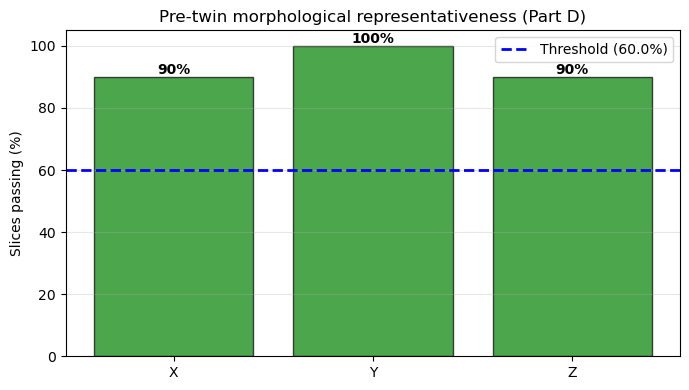

In [27]:
ax_names = list(validator.axis_acceptance.keys())
pct_pass = [validator.axis_acceptance[a]['pct_pass'] for a in ax_names]
colors   = ['green' if validator.axis_acceptance[a]['accepted'] else 'red' for a in ax_names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ax_names, pct_pass, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(P_PERCENTAGE, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({P_PERCENTAGE}%)')
ax.set_ylabel('Slices passing (%)')
ax.set_title('Pre-twin morphological representativeness (Part D)')
ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, pct_pass):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{pct:.0f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## Part E - Conflict-free orientation assignment

### S25  Build neighbour graph and EBSD orientation pools

In [28]:
from upxo.pxtal.twinned_simple_3d import OrientationAssigner3D

oriassign = OrientationAssigner3D(base, rng_seed=42)
oriassign.build_neighbour_graph(connectivity=6)

csl_label = tvf['csl_label']
oriassign.build_ebsd_pools(rg.lfi_ebsd, rg.quat_ebsd, parent_info, csl_label)

OrientationAssigner3D: mode = "conflict_free"
OrientationAssigner3D: neighbour graph (6-connected): 931 grains, 5055 edges
.. User texture information standardisation.

Generating orientations for cryst. texture

.. Caclulating TC wise orientation counts
Building TEX dictionary template

.. TEXTURE INSTANCE NUMBER: 1 of 1

.. Generating ori. clusters around mean texture components
Calculating misorientations across all symmetric equivalents of 'rotated_cube' texture component: 3360 oris
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 3 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 6 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 9 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 12 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 15 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 18 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 21 of 24
.. TC: '{tc_comp}'. M

### S26  Assign host and non-host orientations

In [29]:
oriassign.assign_host_orientations()
oriassign.assign_nonhost_orientations()
oriassign.check_conflicts()

OrientationAssigner3D [L0 conflict_free]: 882 host orientations (fallback: 0)
OrientationAssigner3D [L0 conflict_free]: 49 non-host orientations (fallback: 0)
OrientationAssigner3D: conflict check [PASS] -- 0 adjacent identical-orientation pairs


0

### S27  Pre-twin MDF verification

MC pre-twin MDF          - mean: 40.83 deg, n_pairs: 5055
EBSD parent-state MDF    - mean: 39.10 deg


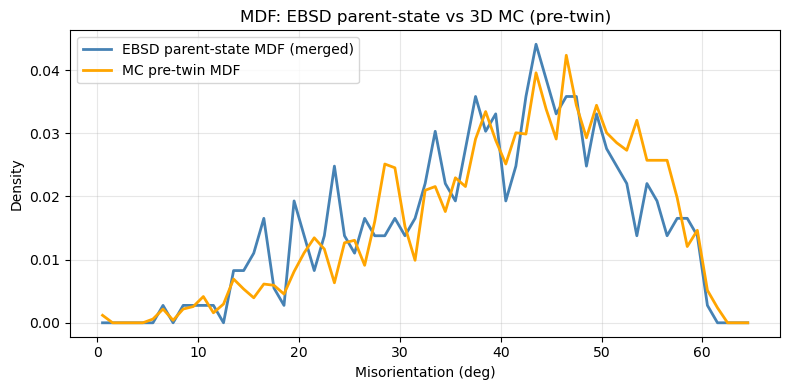

In [30]:
mc_mdf_pre = oriassign.compute_mdf()
print(f'MC pre-twin MDF          - mean: {mc_mdf_pre["mean_angle"]:.2f} deg, '
      f'n_pairs: {mc_mdf_pre["n_pairs"]}')
print(f'EBSD parent-state MDF    - mean: {mdf_merged["mean_angle"]:.2f} deg')

# Compare pre-twin MC against EBSD parent-state (merged) MDF
# -- the full EBSD mdf includes twin boundaries (Sigma3 at ~60 deg)
# -- and the MC structure has no twins yet, so that comparison is unfair.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mdf_merged['hist_bin_centers'], mdf_merged['hist_density'],
        label='EBSD parent-state MDF (merged)', color='steelblue', lw=2)
ax.plot(mc_mdf_pre['hist_bin_centers'], mc_mdf_pre['hist_density'],
        label='MC pre-twin MDF', color='orange', lw=2)
ax.set_xlabel('Misorientation (deg)')
ax.set_ylabel('Density')
ax.set_title('MDF: EBSD parent-state vs 3D MC (pre-twin)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part F - Twin introduction and topology cleaning

### S28  EBSD twin thickness statistics

In [31]:
twin_thickness = rg.compute_mc_twin_thickness(parent_info)

  Twin thickness (minor_axis_length) and intercept statistics (EBSD):
  Metric                              Q1    Q2 (med)        Q3       IQR
  ──────────────────────────────────────────────────────────────────────
  Thickness (µm)                    2.16        3.42      5.99      3.83
  Intercept length (px)             1.00        1.00      8.00      7.00
  Abrupt twins: 599 / 901  (fraction = 0.669)


### S28b  EBSD twin thickness distribution
Histogram and KDE of the EBSD-measured twin lamella thickness.
Use this plot to decide whether the EBSD distribution is appropriate for the
MC domain, or whether a `TWIN_THICK_SCALE_FACTOR != 1.0` is needed in S29.

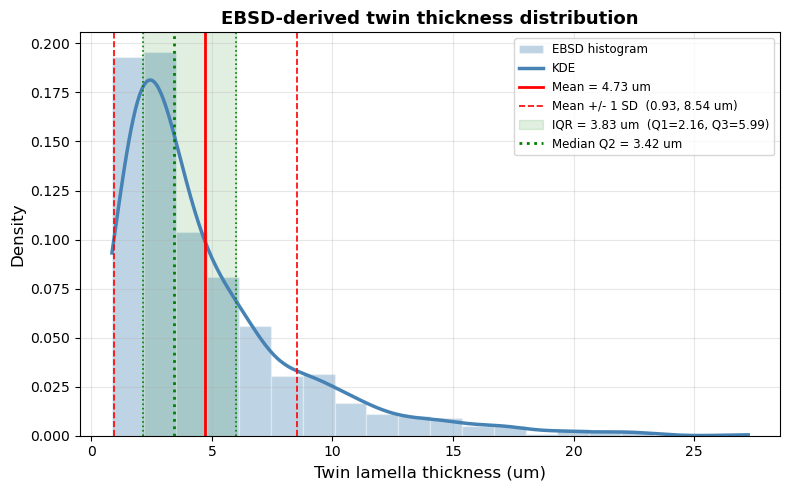

n = 898  |  Mean = 4.733 um  |  Std = 3.802 um  |  Q1/Q2/Q3 = 2.16/3.42/5.99 um  |  IQR = 3.829 um


In [32]:
from scipy.stats import gaussian_kde

thick_um = twin_thickness['thick_um']
if thick_um.size == 0:
    print('No twin thickness data available from EBSD.')
else:
    mean_t = float(np.mean(thick_um))
    std_t  = float(np.std(thick_um))
    q1     = float(np.percentile(thick_um, 25))
    q2     = float(np.percentile(thick_um, 50))
    q3     = float(np.percentile(thick_um, 75))
    iqr    = q3 - q1

    x_kde = np.linspace(thick_um.min(), thick_um.max(), 300)
    kde   = gaussian_kde(thick_um)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(thick_um, bins=20, density=True, alpha=0.35,
            color='steelblue', edgecolor='white', label='EBSD histogram')
    ax.plot(x_kde, kde(x_kde), color='steelblue', lw=2.5, label='KDE')

    # Mean and +/- 1 SD
    ax.axvline(mean_t, color='red', lw=2.0, linestyle='-',
               label=f'Mean = {mean_t:.2f} um')
    ax.axvline(mean_t - std_t, color='red', lw=1.2, linestyle='--',
               label=f'Mean +/- 1 SD  ({mean_t-std_t:.2f}, {mean_t+std_t:.2f} um)')
    ax.axvline(mean_t + std_t, color='red', lw=1.2, linestyle='--')

    # IQR band
    ax.axvspan(q1, q3, alpha=0.12, color='green',
               label=f'IQR = {iqr:.2f} um  (Q1={q1:.2f}, Q3={q3:.2f})')
    ax.axvline(q1, color='green', lw=1.2, linestyle=':')
    ax.axvline(q2, color='green', lw=2.0, linestyle=':',
               label=f'Median Q2 = {q2:.2f} um')
    ax.axvline(q3, color='green', lw=1.2, linestyle=':')

    ax.set_xlabel('Twin lamella thickness (um)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('EBSD-derived twin thickness distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'n = {thick_um.size}  |  '
          f'Mean = {mean_t:.3f} um  |  Std = {std_t:.3f} um  |  '
          f'Q1/Q2/Q3 = {q1:.2f}/{q2:.2f}/{q3:.2f} um  |  '
          f'IQR = {iqr:.3f} um')

In [33]:
# twin_thickness.keys()
# twin_thickness['std']

### S29  Introduce primary and secondary twins

In [34]:
from upxo.pxtal.twinned_simple_3d import TwinGenerator3D

# -- Primary twin configuration ----------------------------------------
N_LAMELLAE_PER_HOST              = 10
TWIN_NUCLEATION_SITE             = 'gb_centroid'  # Options include: 'centroid', 'gb_centroid', 'random_gb'
TVF_TOLERANCE                    = 0.05

# 2D->3D stereological scale factor for twin volume fraction
# EBSD gives a 2D area fraction; set >1 to introduce more twins
# than the 2D fraction suggests (corrects for oblique sectioning
# of textured lamellar features). Default 1.0 = no correction.
# TVF_2D_TO_3D_SCALE_FACTOR: EBSD gives 2D area fraction; primary-loop VF check
# fires before each carving so the last lamella can overshoot the ceiling.
# Set < 1.0 to compensate. 0.75 x EBSD target x 1.05 tol ~ achieved 3D VF.
TVF_2D_TO_3D_SCALE_FACTOR        = 1.15

# Thickness scale factor
TWIN_THICK_SCALE_FACTOR          = 0.80

# Lamella size caps (prevent excessively large twins)
MAX_LAMELLA_THICKNESS_UM = None    # None = no absolute cap; set e.g. 8.0 to limit thickness
MAX_LAMELLA_VF_PER_HOST  = 0.50     # max fraction of host grain volume a single lamella can occupy
"""Example: A 40% cap (0.4) means the lamella cannot span more than ~40% of the grain's 
effective diameter. Scales automatically with grain size — small grains get thin 
lamellae, large grains can accommodate thicker ones, but neither can be dominated
by a single lamella. The lower bound (min_lamella_thickness) is always enforced 
last, so the cap never produces a degenerate thin lamella."""

# Separation / contact probabilities for k>=1 lamellae (must sum to 1)
PROB_LAMELLA_SEPARATED           = 0.30
PROB_LAMELLA_CONTACTING          = 0.70

# Secondary twin nucleation mode probabilities (must sum to 1)
PROB_SECONDARY_OUTWARD_TWIN_NUCLEATION = 0.60
PROB_SECONDARY_INWARD_TWIN_NUCLEATION  = 0.40

# -- Schmid factor configuration ----------------------------------------
# Reference direction for Schmid factor computation (sample frame).
# For annealing twins use the sample normal or rolling direction.
SCHMID_LOADING_DIRECTION         = (0., 0., 1.)  # ND = sample normal
# >0: reorder hosts by max Schmid factor before introduction
# (0 = keep volume+adjacency rank; 1 = Schmid-rank only)
HOST_SCHMID_WEIGHT               = 1.0
# True: highest-Schmid {111} plane used as primary twin plane
USE_SCHMID_FOR_VARIANT_SEL       = True

twinmake = TwinGenerator3D(
    base,
    n_lamellae_per_host                   = N_LAMELLAE_PER_HOST,
    twin_nucleation_site                  = TWIN_NUCLEATION_SITE,
    tvf_tolerance                         = TVF_TOLERANCE,
    twin_orient_scatter_deg               = 1.5,
    meshing_route                         = 'conformal',
    twin_thick_scale_factor               = TWIN_THICK_SCALE_FACTOR,
    tvf_2d_to_3d_scale_factor             = TVF_2D_TO_3D_SCALE_FACTOR,
    max_lamella_thickness_um              = MAX_LAMELLA_THICKNESS_UM,
    max_lamella_vf_per_host               = MAX_LAMELLA_VF_PER_HOST,
    prob_lamella_separated                = PROB_LAMELLA_SEPARATED,
    prob_lamella_contacting               = PROB_LAMELLA_CONTACTING,
    prob_secondary_outward_twinNucleation = PROB_SECONDARY_OUTWARD_TWIN_NUCLEATION,
    prob_secondary_inward_twinNucleation  = PROB_SECONDARY_INWARD_TWIN_NUCLEATION,
    schmid_loading_direction              = SCHMID_LOADING_DIRECTION,
    host_schmid_weight                    = HOST_SCHMID_WEIGHT,
    use_schmid_for_variant_selection      = USE_SCHMID_FOR_VARIANT_SEL,
    rng_seed=123,
)

twinmake.introduce_primary_twins(
    oriassign.all_grain_orientations, twin_thickness, tvf=tvf)
twinmake.introduce_secondary_twins(tvf, twin_thickness)

twinmake.print_summary()

TwinGenerator3D WARNING: selected CSL "S13b" but only "S3  (twin)" is supported (Path A). Twin orientations will still use Sigma3.
  [S29] Building grain voxel index... done  931 grains  (0.1s)
TwinGenerator3D NOTE: twin_nucleation_site="gb_centroid" overridden for contacting lamellae (geometric offset).
TwinGenerator3D (primary): 397 twins across 106/882 hosts
  NOTE: VF target reached — introduction stopped early.
TwinGenerator3D: secondary stopped — VF target reached.
TwinGenerator3D: secondary twins: 0 (outward 2a: 0, inward 2b: 0)
TwinGenerator3D  —  Introduction Summary

CONFIGURATION
  n_lamellae_per_host              : 10
  twin_nucleation_site             : gb_centroid
  meshing_route                    : conformal
  twin_orient_scatter_deg          : 1.5
  twin_thick_scale_factor          : 0.8
  tvf_2d_to_3d_scale_factor        : 1.15
  schmid_loading_direction         : (0.0, 0.0, 1.0)
  host_schmid_weight               : 1.0  (Schmid-ranked hosts)
  use_schmid_for_variant_

### S30  Topology cleaning (spike removal + lobe splitting)

In [35]:
from upxo.pxtal.twinned_simple_3d import StructureCleaner3D

cleaner = StructureCleaner3D(upscale_fallback=False, split_jitter_deg=0.0, rng_seed=7)
cleaner.clean(
    twinmake.lgi_twinned,
    twinmake.all_quats,
    twinmake.twin_role,
    twinmake.twin_parent_of,
)
print(cleaner.split_events_report())

[S30] StructureCleaner3D  domain=100x100x100  active_vox=1,000,000  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  521 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  516 splits  skipped 0 small grains  (1.1s)
StructureCleaner3D: PASS (spikes removed: 521, lobes split: 516)
Split events: 516
  1329 <- parent 1076 | 70 vox (same orientation)
  1330 <- parent 1315 | 5 vox (same orientation)
  1331 <- parent 850 | 198 vox (same orientation)
  1332 <- parent 850 | 84 vox (same orientation)
  1333 <- parent 1313 | 3 vox (same orientation)
  1334 <- parent 1077 | 24 vox (same orientation)
  1335 <- parent 1314 | 2 vox (same orientation)
  1336 <- parent 1314 | 2 vox (same orientation)
  1337 <- parent 770 | 5 vox (same orientation)
  1338 <- parent 770 | 3 vox (same orientation)
  1339 <- parent 1253 | 7 vox (same orientation)
  1340 <- parent 1081 | 7 vox (same orientation)
  1341 <- parent 1080 | 33 vox (same orientation)
  1342 <- parent 852 | 3 vox (same orientation)

## Part G - Post-twin crystallographic representativeness

### S31  Build post-twin voxel quaternion field

In [36]:
quat_3d_clean = np.zeros(cleaner.lgi_clean.shape + (4,), dtype=np.float64)
for gid, q in cleaner.all_quats_clean.items():
    quat_3d_clean[cleaner.lgi_clean == gid] = q
print(f'quat_3d_clean: {quat_3d_clean.shape}')

quat_3d_clean: (100, 100, 100, 4)


### S32  Post-twin crystallographic slice validation

In [37]:
ebsd_miso = mdf['miso_deg'] if isinstance(mdf, dict) else mdf

validator_h = RepresentativenessValidator3D(
    n_slices_x=N_SLICES_X, n_slices_y=N_SLICES_Y, n_slices_z=N_SLICES_Z,
    p_percentage=P_PERCENTAGE, wasserstein_threshold=5.0,
)
validator_h.validate_crystallographic(cleaner.lgi_clean, quat_3d_clean, ebsd_miso)
print(validator_h.report())

3D Representativeness Validation
X-axis: 10/10 (100.0%) [ACCEPTED]
Y-axis: 10/10 (100.0%) [ACCEPTED]
Z-axis: 9/10 (90.0%) [ACCEPTED]

Overall 3D acceptance: YES
Threshold: 60.0% per axis


### S33  Post-twin MDF verification

Post-twin MDF mean: 42.93 deg


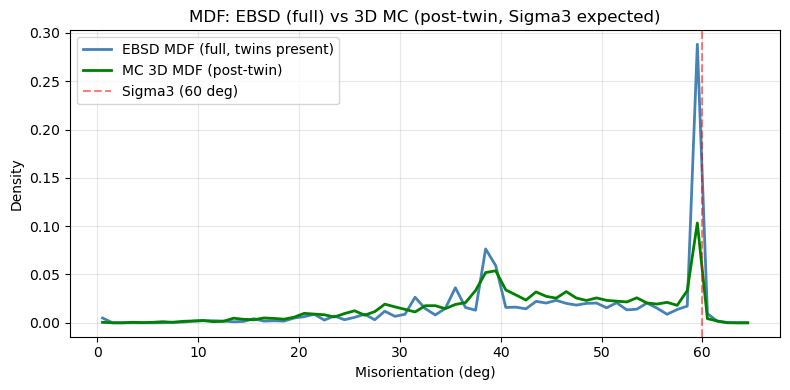

In [38]:
from upxo.xtalphy.crystal_orientation import compute_mdf_from_quats
from upxo.gsdataops.gid_ops import find_neighs3d

neigh_clean_raw = find_neighs3d(cleaner.lgi_clean.astype(np.int32), conn=6)
neigh_clean = {int(g): [int(n) for n in ns] for g, ns in neigh_clean_raw.items()}
mc_mdf_post = compute_mdf_from_quats(
    cleaner.lgi_clean, quat_3d_clean, neigh_clean, n_bins=65, angle_range=(0.0, 65.0))

print(f'Post-twin MDF mean: {mc_mdf_post["mean_angle"]:.2f} deg')

fig, ax = plt.subplots(figsize=(8, 4))
if isinstance(mdf, dict):
    ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], label='EBSD MDF (full, twins present)', color='steelblue', lw=2)
else:
    ax.hist(mdf, bins=65, range=(0,65), density=True, alpha=0.5, label='EBSD MDF (full, twins present)', color='steelblue')
ax.plot(mc_mdf_post['hist_bin_centers'], mc_mdf_post['hist_density'],
        label='MC 3D MDF (post-twin)', color='green', lw=2)
ax.axvline(60.0, color='red', linestyle='--', alpha=0.5, label='Sigma3 (60 deg)')
ax.set_xlabel('Misorientation (deg)'); ax.set_ylabel('Density')
ax.set_title('MDF: EBSD (full) vs 3D MC (post-twin, Sigma3 expected)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### S33b  MDF of representative 2D slices (post-twin)
Recomputes MDF for every slice that *passed* the crystallographic
representativeness test in S32.  Individual passing slices are thin
semi-transparent lines; the per-axis mean is a thick line.
Colour key: X-normal = red, Y-normal = blue, Z-normal = green.

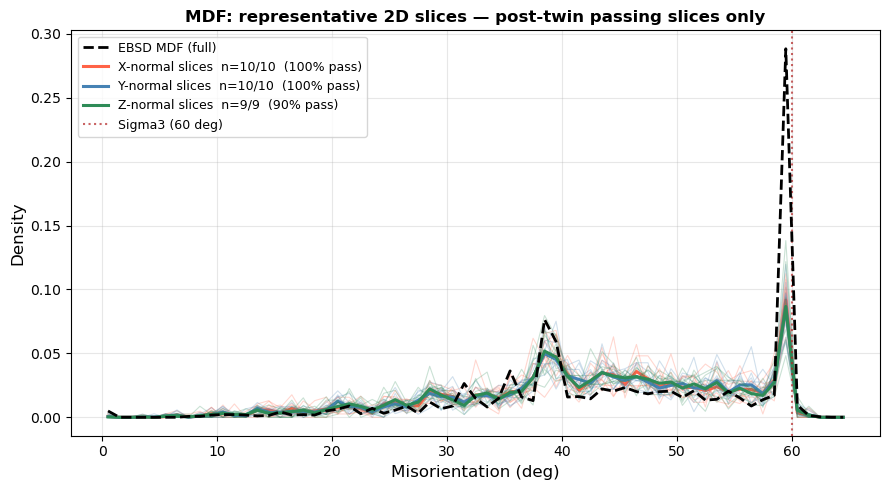

In [39]:
from upxo.gsdataops.gid_ops import find_neighs2d
from upxo.gsdataops.grid_ops import extract_2d_slice_pair

axis_colors  = {'X': 'tomato',    'Y': 'steelblue', 'Z': 'seagreen'}
axis_map     = {'X': 0,           'Y': 1,           'Z': 2}

fig, ax = plt.subplots(figsize=(9, 5))

# EBSD reference
ebsd_miso = mdf['miso_deg'] if isinstance(mdf, dict) else mdf
_h, _e = np.histogram(ebsd_miso, bins=65, range=(0.0, 65.0), density=True)
_c = 0.5 * (_e[:-1] + _e[1:])
ax.plot(_c, _h, color='black', lw=2, linestyle='--',
        label='EBSD MDF (full)', zorder=10)

for axis_name, color in axis_colors.items():
    ax_int = axis_map[axis_name]

    if axis_name not in validator_h.slice_results:
        continue

    # Only use slices that passed the representativeness test in S32
    passing = [r['slice_idx'] for r in validator_h.slice_results[axis_name]
               if r['passes']]
    pct = validator_h.axis_acceptance.get(axis_name, {}).get('pct_pass', 0)

    if not passing:
        print(f'{axis_name}-axis: no passing slices ({pct:.0f}%)')
        continue

    densities = []
    bin_centers = None

    for slice_idx in passing:
        lgi_2d, quat_2d = extract_2d_slice_pair(
            cleaner.lgi_clean, quat_3d_clean, ax_int, int(slice_idx))
        if lgi_2d.max() <= 0:
            continue
        try:
            neigh_raw = find_neighs2d(lgi_2d.astype(np.int32), conn=4)
            neigh = {int(g): [int(n) for n in ns]
                     for g, ns in neigh_raw.items()}
            smdf = compute_mdf_from_quats(
                lgi_2d, quat_2d, neigh, n_bins=65, angle_range=(0.0, 65.0))
            densities.append(smdf['hist_density'])
            bin_centers = smdf['hist_bin_centers']
            ax.plot(smdf['hist_bin_centers'], smdf['hist_density'],
                    color=color, alpha=0.25, lw=0.8)
        except Exception:
            pass

    if densities and bin_centers is not None:
        mean_d = np.mean(densities, axis=0)
        ax.plot(bin_centers, mean_d, color=color, lw=2.2,
                label=f'{axis_name}-normal slices  '
                      f'n={len(densities)}/{len(passing)}  '
                      f'({pct:.0f}% pass)')

ax.axvline(60.0, color='firebrick', linestyle=':', lw=1.5, alpha=0.7,
           label='Sigma3 (60 deg)')
ax.set_xlabel('Misorientation (deg)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('MDF: representative 2D slices — post-twin passing slices only',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### S33c  Twin thickness distributions - 2D slices vs EBSD reference
For each 2D slice (same X/Y/Z axis configuration as Parts D and G),
the minor-axis length of every twin region visible in that slice is
computed as a thickness proxy and converted to microns.  Thin lines
show individual slice distributions; thick lines show the per-axis
mean.  The EBSD reference (black dashed) is from twin_thickness[thick_um]
(S28).

Colour key: X-normal = red, Y-normal = blue, Z-normal = green.
Reuses N_SLICES_X/Y/Z and TEST_ALONG_X/Y/Z from Part D.

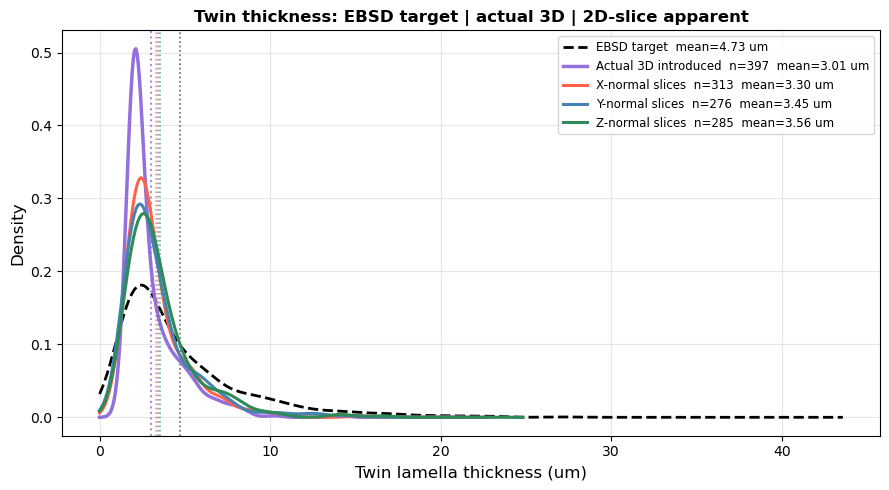

EBSD target mean   : 4.733 um
Actual 3D mean     : 3.015 um  (ratio to EBSD: 0.64x)


In [40]:
from scipy.stats import gaussian_kde
from skimage.measure import regionprops
from upxo.gsdataops.grid_ops import section_from_3d

axis_colors = {'X': 'tomato', 'Y': 'steelblue', 'Z': 'seagreen'}
axis_cfg    = [
    ('X', 0, N_SLICES_X, TEST_ALONG_X),
    ('Y', 1, N_SLICES_Y, TEST_ALONG_Y),
    ('Z', 2, N_SLICES_Z, TEST_ALONG_Z),
]
twin_role_set = {'primary_twin', 'secondary_twin'}

# EBSD reference
ebsd_thick  = twin_thickness['thick_um']
ebsd_mean_t = float(np.mean(ebsd_thick)) if ebsd_thick.size > 0 else 0.0

# Actual 3D introduced thicknesses (stored during twin introduction)
# twin_halfwidths_vox stores hw per twin grain ID; full thickness = 2 * hw * vox_size
actual_thick_um = np.array([
    2.0 * hw * pxt.vox_size
    for hw in twinmake.twin_halfwidths_vox.values()
])
actual_mean_t = float(np.mean(actual_thick_um)) if actual_thick_um.size > 0 else 0.0

fig, ax = plt.subplots(figsize=(9, 5))

# ── EBSD reference KDE (black dashed) ─────────────────────────────────────
if ebsd_thick.size > 1:
    x_ref   = np.linspace(0, max(ebsd_thick.max(), actual_thick_um.max() if actual_thick_um.size > 0 else 0) * 1.6, 300)
    kde_ref = gaussian_kde(ebsd_thick)
    ax.plot(x_ref, kde_ref(x_ref), color='black', lw=2, linestyle='--',
            label=f'EBSD target  mean={ebsd_mean_t:.2f} um')
    ax.axvline(ebsd_mean_t, color='black', lw=1.2, linestyle=':', alpha=0.6)

# ── Actual 3D introduced thickness KDE (purple solid) ─────────────────────
if actual_thick_um.size > 1:
    kde_act = gaussian_kde(actual_thick_um)
    x_act   = np.linspace(0, actual_thick_um.max() * 1.5, 300)
    ax.plot(x_act, kde_act(x_act), color='mediumpurple', lw=2.5, linestyle='-',
            label=f'Actual 3D introduced  n={actual_thick_um.size}  '
                  f'mean={actual_mean_t:.2f} um')
    ax.axvline(actual_mean_t, color='mediumpurple', lw=1.5, linestyle=':', alpha=0.8)

# ── Per-axis 2D apparent thickness from regionprops (red / blue / green) ──
for axis_name, ax_int, n_slices, test_enabled in axis_cfg:
    if not test_enabled:
        continue
    color = axis_colors[axis_name]
    domain_size   = cleaner.lgi_clean.shape[ax_int]
    slice_indices = np.linspace(0, domain_size - 1, n_slices, dtype=int)

    all_thick_um = []
    slice_kdes   = []
    x_plot       = None

    for slice_idx in slice_indices:
        lgi_2d = section_from_3d(cleaner.lgi_clean, axis=ax_int,
                                  location=int(slice_idx))
        slice_gids = set(int(g) for g in np.unique(lgi_2d) if g > 0)
        twin_gids  = slice_gids & {
            g for g, r in cleaner.twin_role_clean.items() if r in twin_role_set}

        for gid in twin_gids:
            mask = (lgi_2d == gid)
            if np.sum(mask) < 4:
                continue
            rp = regionprops(mask.astype(np.uint8))
            if rp and rp[0].minor_axis_length > 0:
                all_thick_um.append(rp[0].minor_axis_length * pxt.vox_size)

    if len(all_thick_um) > 1:
        arr   = np.array(all_thick_um)
        mean_t = float(np.mean(arr))
        x_hi   = max(arr.max() * 1.5, 0.1)
        x_s    = np.linspace(0, x_hi, 200)
        kde_s  = gaussian_kde(arr)
        ax.plot(x_s, kde_s(x_s), color=color, lw=2.2,
                label=f'{axis_name}-normal slices  n={len(all_thick_um)}  '
                      f'mean={mean_t:.2f} um')
        ax.axvline(mean_t, color=color, lw=1.2, linestyle=':', alpha=0.7)
    else:
        print(f'{axis_name}-axis: insufficient twin data in slices.')

ax.set_xlabel('Twin lamella thickness (um)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Twin thickness: EBSD target | actual 3D | 2D-slice apparent',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'EBSD target mean   : {ebsd_mean_t:.3f} um')
print(f'Actual 3D mean     : {actual_mean_t:.3f} um  '
      f'(ratio to EBSD: {actual_mean_t/ebsd_mean_t:.2f}x)' if ebsd_mean_t > 0 else '')

## Part H - Visualisation and export

### S34  3D PyVista render

In [49]:
from upxo.pxtal.twinned_simple_3d.viz_3d import render_3d
render_3d(cleaner.lgi_clean, cleaner.twin_role_clean, role_opacity={'non_host': 0.5, 
                                                                    'host': 0.75,
                                                                    'primary_twin': 1.0,
                                                                    'secondary_twin': 1.0})

Widget(value='<iframe src="http://localhost:54568/index.html?ui=P_0x2e0b9f91a90_5&reconnect=auto" class="pyvis…

### S35  IPF-coloured 2D slice

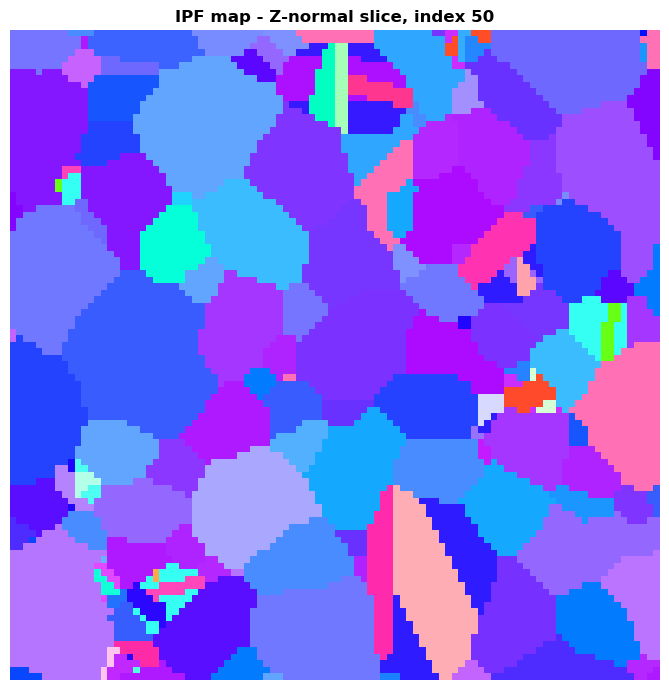

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'IPF map - Z-normal slice, index 50'}>)

In [42]:
from upxo.pxtal.twinned_simple_3d.viz_3d import plot_ipf_slice

VIZ_AXIS = 2  # 0=X, 1=Y, 2=Z
plot_ipf_slice(cleaner.lgi_clean, cleaner.all_quats_clean, axis=VIZ_AXIS)

### S36  Export final structure to disk

In [43]:
import os, pickle

OUT_DIR_3D = r'C:/Development/UPXO/upxo_library/data/gs'
os.makedirs(OUT_DIR_3D, exist_ok=True)

np.save(os.path.join(OUT_DIR_3D, 'lgi_twinned_clean.npy'), cleaner.lgi_clean)
with open(os.path.join(OUT_DIR_3D, 'orientations_all.pkl'), 'wb') as f:
    pickle.dump(cleaner.all_quats_clean, f)
with open(os.path.join(OUT_DIR_3D, 'twin_role.pkl'), 'wb') as f:
    pickle.dump(cleaner.twin_role_clean, f)
with open(os.path.join(OUT_DIR_3D, 'twin_parent_of.pkl'), 'wb') as f:
    pickle.dump(cleaner.twin_parent_of_clean, f)

print(f'Exported to: {OUT_DIR_3D}')
print('  lgi_twinned_clean.npy')
print('  orientations_all.pkl')
print('  twin_role.pkl')
print('  twin_parent_of.pkl')

Exported to: C:/Development/UPXO/upxo_library/data/gs
  lgi_twinned_clean.npy
  orientations_all.pkl
  twin_role.pkl
  twin_parent_of.pkl


### S37  Final summary report

In [44]:
from upxo.pxtal.twinned_simple_3d.feature_props_3d import (
    grain_role_statistics,
    compute_ebsd_mc_comparison_stats,
    print_ebsd_mc_comparison,
)
from upxo.gsdataops.grid_ops import section_from_3d
from skimage.measure import regionprops

# ── 1. Role statistics ───────────────────────────────────────────────────
vols       = {gid: int(np.sum(cleaner.lgi_clean == gid))
              for gid in (int(g) for g in np.unique(cleaner.lgi_clean) if g > 0)}
role_stats = grain_role_statistics(vols, cleaner.twin_role_clean, base.voxel_size)

# ── 2. EBSD reference dict ───────────────────────────────────────────────
# Fix: use rg.lfi_ebsd (original, not merged) for parent grain IDs
# Use S3 (twin) parents — physically the relevant host grain system
_host_csl = 'S3  (twin)' if 'S3  (twin)' in parent_info else tvf['csl_label']
ebsd_parent_gids = parent_info[_host_csl]['pure_parents']
ebsd_host_eqdia  = np.array([
    float(2.0 * np.sqrt(np.sum(rg.lfi_ebsd == gid)
                        * rg.ebsd_step**2 / np.pi))
    for gid in ebsd_parent_gids
    if np.sum(rg.lfi_ebsd == gid) > 0
])

ebsd_ref = {
    'miso_deg_full':   mdf['miso_deg'] if isinstance(mdf, dict) else mdf,
    'miso_deg_merged': mdf_merged['miso_deg'],
    'twin_thick_um':   twin_thickness['thick_um'],
    'host_eqdia_um':   ebsd_host_eqdia,
    'tvf_2d':          tvf['overall_twin_frac'],
}

# ── 3. MC reference dict ─────────────────────────────────────────────────
# MC apparent 2D thickness: regionprops minor_axis_length on slices
mc_twin_thick_2d = []
twin_gids_set = {g for g, r in cleaner.twin_role_clean.items()
                  if r in ('primary_twin', 'secondary_twin')}
for _ax in range(3):
    for _idx in np.linspace(0, cleaner.lgi_clean.shape[_ax]-1, N_SLICES_X, dtype=int):
        _s = section_from_3d(cleaner.lgi_clean, axis=_ax, location=int(_idx))
        for _gid in (set(int(g) for g in np.unique(_s) if g > 0) & twin_gids_set):
            _mask = (_s == _gid)
            if np.sum(_mask) < 4: continue
            _rp = regionprops(_mask.astype(np.uint8))
            if _rp and _rp[0].minor_axis_length > 0:
                mc_twin_thick_2d.append(_rp[0].minor_axis_length * pxt.vox_size)
mc_twin_thick_2d = np.array(mc_twin_thick_2d)

# MC actual 3D thickness from stored half-widths
mc_twin_thick_3d = np.array([
    2.0 * hw * pxt.vox_size
    for hw in twinmake.twin_halfwidths_vox.values()
]) if twinmake.twin_halfwidths_vox else np.array([])

# MC host grain eq-diameters
mc_host_eqdia = np.array([
    base.mprop['eqdia'][gid]
    for gid in base.host_grain_ids
    if gid in base.mprop.get('eqdia', {})
]) if base.host_grain_ids else np.array([])

# Per-slice 2D twin VF
tvf_2d_slices = []
for _ax in range(3):
    _dom = cleaner.lgi_clean.shape[_ax]
    for _idx in np.linspace(0, _dom - 1, N_SLICES_X, dtype=int):
        _s   = section_from_3d(cleaner.lgi_clean, axis=_ax, location=int(_idx))
        _tot = int(np.sum(_s > 0))
        _twn = int(np.sum(np.isin(_s, list(twin_gids_set))))
        if _tot > 0:
            tvf_2d_slices.append(_twn / _tot)

# -- Final twin VF from cleaned structure --------------------------------
twin_gids_final = {g for g, r in cleaner.twin_role_clean.items()
                    if r in ("primary_twin", "secondary_twin")}
_tot_clean = int(np.sum(cleaner.lgi_clean > 0))
_twin_clean = sum(int(np.sum(cleaner.lgi_clean == g)) for g in twin_gids_final)
tvf_final_3d = _twin_clean / _tot_clean if _tot_clean > 0 else 0.0

mc_ref = {
    'miso_deg_posttwin':        mc_mdf_post['miso_deg'],
    'twin_thick_apparent_2d_um': mc_twin_thick_2d,
    'twin_thick_3d_um':          mc_twin_thick_3d,
    'host_eqdia_um':             mc_host_eqdia,
    'tvf_2d_slices':             np.array(tvf_2d_slices),
    'tvf_3d':                    tvf_final_3d,   # final, post-cleaning
}

# ── 4. Print comparison ──────────────────────────────────────────────────
cmp_stats = compute_ebsd_mc_comparison_stats(ebsd_ref, mc_ref)
print_ebsd_mc_comparison(cmp_stats)

# ── 5. Role volume stats ─────────────────────────────────────────────────
print('\nGRAIN ROLE VOLUME STATISTICS (MC)')
print('-' * 72)
for role, st in role_stats.items():
    print(f'  {role:<18} n={st["count"]:>4}  '
          f'mean={st["mean_vol_um3"]:>8.1f}  '
          f'std={st["std_vol_um3"]:>8.1f} um3')

print('\nPipeline complete: Parts A-H.')

print('\nFINAL TWIN VOLUME FRACTION  (post-cleaning, authoritative)')
print('-' * 72)
_n_prim = len([g for g,r in cleaner.twin_role_clean.items() if r=='primary_twin'])
_n_sec  = len([g for g,r in cleaner.twin_role_clean.items() if r=='secondary_twin'])
print(f'  Primary twins        : {_n_prim} grains')
print(f'  Secondary twins      : {_n_sec} grains')
print(f'  Twin voxels          : {_twin_clean:,}')
print(f'  Total domain voxels  : {_tot_clean:,}')
print(f'  Twin VF (3D, final)  : {tvf_final_3d:.4f}   ({100*tvf_final_3d:.2f}%)')
_ebsd_tvf = tvf['overall_twin_frac']
print(f'  EBSD 2D area frac    : {_ebsd_tvf:.4f}   ({100*_ebsd_tvf:.2f}%)')
print(f'  Ratio  3D / 2D       : {tvf_final_3d/_ebsd_tvf:.3f}x')


EBSD vs Synthetic MC  --  Statistical Comparison

MISORIENTATION DISTRIBUTION (MDF)
Property                            EBSD (full)  EBSD (merged)  SGC post-twin
------------------------------------------------------------------------
  Mean                                   46.18       39.10       42.93  deg
  Std dev                                12.69       12.02       12.05  deg
  Q1                                     38.42       31.68       36.21  deg
  Median                                 46.88       40.94       43.22  deg
  Q3                                     59.63       47.96       52.93  deg
  n (boundary pairs)                      2837         363        9638

TWIN LAMELLA THICKNESS  (EBSD=2D apparent; MC apparent=regionprops on slices; MC actual=2xhw from introduction)
Property                            EBSD apparent 2D  SGC apparent 2D  SGC actual 3D
------------------------------------------------------------------------
  Mean                                    4